In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# df=pd.read_csv("simple_linear_regression.csv")
# df.head(5)
dict={'rate':[12,13,14,14],'states':['a','b','c','d']}
df1=pd.DataFrame(dict)
df1=df1.set_index("states")
df1
df2=pd.DataFrame(dict,index=[21,22,23,24])
df2.loc['h']=[1,2]
df2.loc[22,'states']=10
df2

,rate,states
21,12,a
22,13,10
23,14,c
24,14,d
h,1,2


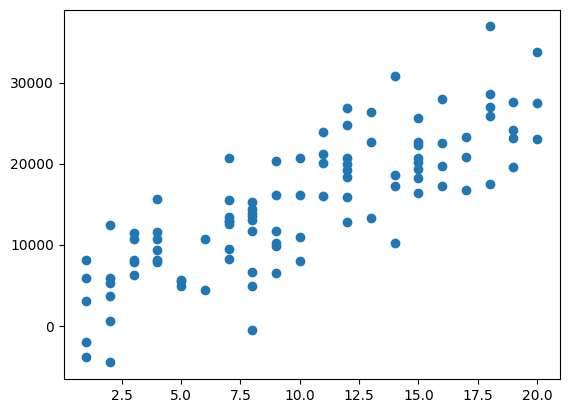

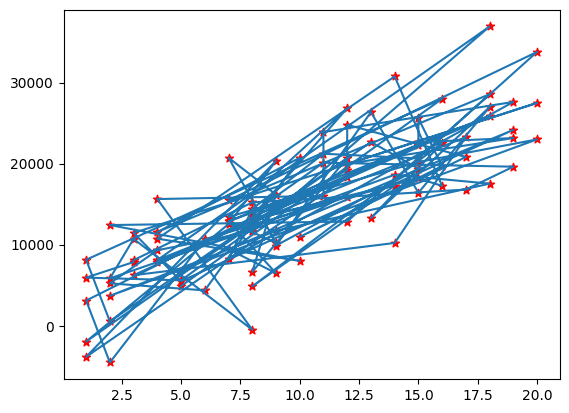

In [4]:
plt.scatter(df["Experience_Years"],df["Salary"])
plt.show()
plt.scatter(df["Experience_Years"],df["Salary"],color='red',marker='*')
plt.plot(df["Experience_Years"],df["Salary"])

In [5]:
x=df[["Experience_Years"]]
y=df["Salary"]
print(x)

    Experience_Years
0                  7
1                 20
2                 15
3                 11
4                  8
..               ...
95                12
96                 2
97                 1
98                16
99                 5

[100 rows x 1 columns]


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.75,random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [8]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression(n_jobs=-1)
# Initialize Linear Regression model with parallel processing
#Tells the model to use all available CPU cores during training (can speed things up on large datasets).
lr.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

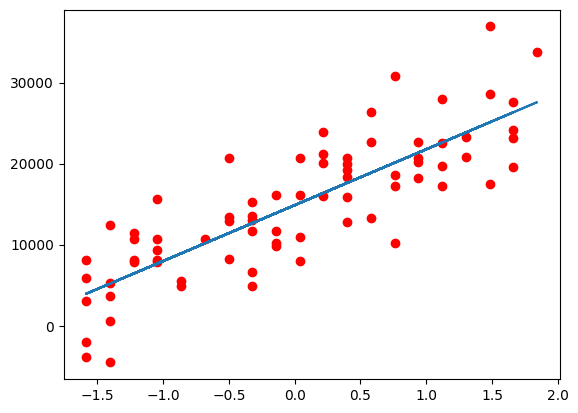

In [9]:
plt.scatter(x_train,y_train,color='red')
plt.plot(x_train,lr.predict(x_train))

In [10]:
y_pred=lr.predict(x_test)

In [11]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mae)
print(mse)
rmse

3814.27673859539
24640004.46294062


np.float64(4963.869907938827)

In [12]:
lr.predict(sc.transform([[20]]))

C:\Users\Varshitha\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([27572.39860653])

In [19]:
print(lr.coef_)
lr.intercept_

[6894.78390033]


np.float64(14868.93129693494)

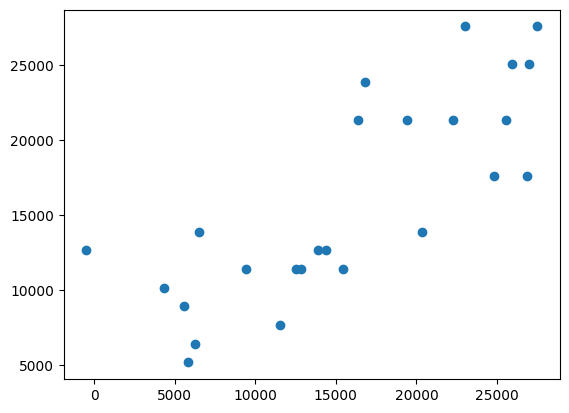

In [20]:
plt.scatter(y_test,y_pred)

**RIDGE REGRESSION**

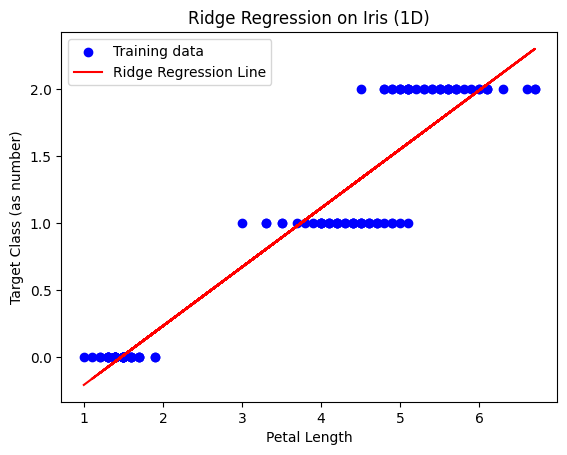

Mean Squared Error: 0.06351096827725951
Ridge Coefficients: [0.43946567]


In [34]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_iris

# Load the iris dataset
data = load_iris()
x = data.data[:, 2].reshape(-1, 1)  # Use just one feature: petal length
y = data.target

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create Ridge Regression model
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

# Predict
y_pred = ridge.predict(x_test)

# Plot
plt.scatter(x_train, y_train, color='blue', label='Training data')
plt.plot(x_train, ridge.predict(x_train), color='red', label='Ridge Regression Line')
plt.legend()
plt.xlabel("Petal Length")
plt.ylabel("Target Class (as number)")
plt.title("Ridge Regression on Iris (1D)")
plt.show()

# Evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Ridge Coefficients:", ridge.coef_)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_iris

data = load_iris()
x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create Ridge Regression model with alpha=1.0
ridge = Ridge(alpha=1.0)

# Train the model
ridge.fit(x_train, y_train)
y_pred = ridge.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Ridge Coefficients:", ridge.coef_)

Mean Squared Error: 0.06677344873438022
Ridge Coefficients: [ 0.         -0.          0.40782891  0.        ]


ValueError: x and y must be the same size

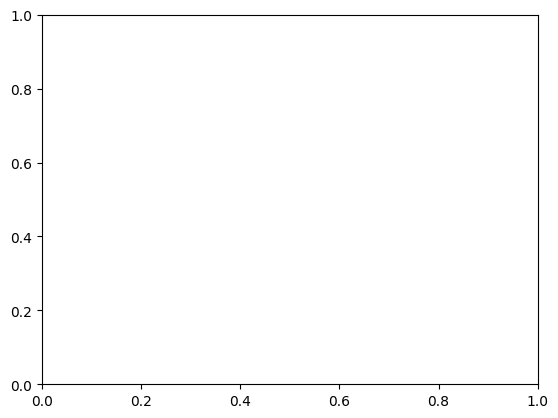

In [32]:
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train))
# Plotting error: You're trying to plot a regression line 
# over multi-dimensional input (x_train), but plt.plot works best with 1D data.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_boston

data = load_boston()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Ridge Regression model with alpha=1.0
ridge = Ridge(alpha=1.0)

# Train the model
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Ridge Coefficients:", ridge.coef_)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_boston
boston = load_boston()
boston_df=pd.DataFrame(boston.data,columns=boston.feature_name
s)
#target variable
boston_df['Price']=boston.target
#Exploration
plt.figure(figsize = (10, 10))
sns.heatmap(boston_df.corr(), annot = True)
#There are cases of multicolinearity, we will drop a few

In [ ]:
#There are cases of multicolinearity, we will drop a few
# columns
boston_df.drop(columns = ["INDUS", "NOX"], inplace = True)
#we will log the LSTAT Column
boston_df.LSTAT = np.log(boston_df.LSTAT)
# Note that we logged the LSTAT column as it doesn’t have a linear relationship with
# the price column. Linear models assume a linear relationship between x and y
# variables.

In [ ]:
#data splitting and scaling
features = boston_df.columns[0:11]
target = boston_df.columns[-1]
#X and y values
X = boston_df[features].values
y = boston_df[target].values
#splot
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.3, random_state=17)
print("The dimension of X_train is {}".format(X_train.shape))
print("The dimension of X_test is {}".format(X_test.shape))
#Scale features
scaler = StandardScaler()
X_train = scaler.fit_transf

Lasso Regression
Selecting Optimal Alpha Values Using Cross-Validation in Sklearn
We may need to try out different alpha values to find the optimal constraint value.
For this case, we can use the cross-validation model in the sklearn package. This
will try out different combinations of alpha values and then choose the best model.

In [ ]:
#Using the linear CV model
from sklearn.linear_model import LassoCV
#Lasso Cross validation
lasso_cv = LassoCV(alphas = [0.0001, 0.001,0.01, 0.1, 1, 10],
random_state=0).fit(X_train, y_train)
#score
print(lasso_cv.score(X_train, y_train))
print(lasso_cv.score(X_test, y_test))

In [ ]:
#Ridge Regression Model
ridgeReg = Ridge(alpha=10)
ridgeReg.fit(X_train,y_train)
#train and test score for ridge regression
train_score_ridge = ridgeReg.score(X_train, y_train)
test_score_ridge = ridgeReg.score(X_test, y_test)
print("The train score for ridge model is{}".format(train_score_ridge))
print("The test score for ridge model is{}".format(test_score_ridge))